In [2]:
#Imports

import os
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import tensorflow as tf
from collections import Counter

In [3]:
data_dir = Path(r"C:\Users\user\Documents\Agriculture & Smart Farming\PlantVillage_color")

In [4]:
total_images = 0

for class_name in os.listdir(data_dir):
    class_path = data_dir / class_name
    
    if class_path.is_dir():
        num_images = len(os.listdir(class_path))
        total_images += num_images

print("Total Images:", total_images)

Total Images: 54305


In [5]:
#Exploratory Data Analysis(EDA)
#Class Distribution

class_counts = {}

for class_name in os.listdir(data_dir):
    class_path = data_dir / class_name
    if class_path.is_dir():
        class_counts[class_name] = len(os.listdir(class_path))

# Print counts
for k, v in class_counts.items():
    print(f"{k}: {v}")

Apple___Apple_scab: 630
Apple___Black_rot: 621
Apple___Cedar_apple_rust: 275
Apple___healthy: 1645
Blueberry___healthy: 1502
Cherry_(including_sour)___healthy: 854
Cherry_(including_sour)___Powdery_mildew: 1052
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 513
Corn_(maize)___Common_rust_: 1192
Corn_(maize)___healthy: 1162
Corn_(maize)___Northern_Leaf_Blight: 985
Grape___Black_rot: 1180
Grape___Esca_(Black_Measles): 1383
Grape___healthy: 423
Grape___Leaf_blight_(Isariopsis_Leaf_Spot): 1076
Orange___Haunglongbing_(Citrus_greening): 5507
Peach___Bacterial_spot: 2297
Peach___healthy: 360
Pepper,_bell___Bacterial_spot: 997
Pepper,_bell___healthy: 1478
Potato___Early_blight: 1000
Potato___healthy: 152
Potato___Late_blight: 1000
Raspberry___healthy: 371
Soybean___healthy: 5090
Squash___Powdery_mildew: 1835
Strawberry___healthy: 456
Strawberry___Leaf_scorch: 1109
Tomato___Bacterial_spot: 2127
Tomato___Early_blight: 1000
Tomato___healthy: 1591
Tomato___Late_blight: 1909
Tomato___Leaf_Mold

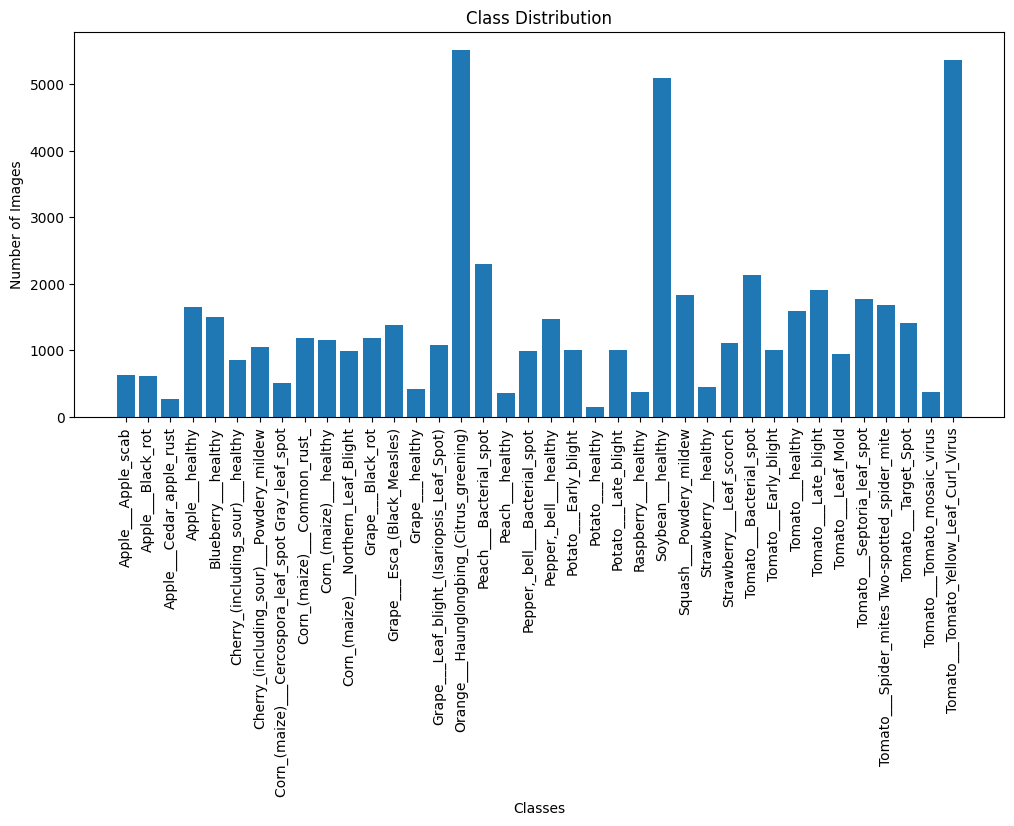

In [6]:
#Plot Class Distribution

plt.figure(figsize=(12,5))
plt.bar(class_counts.keys(), class_counts.values())
plt.xticks(rotation=90)
plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.show()

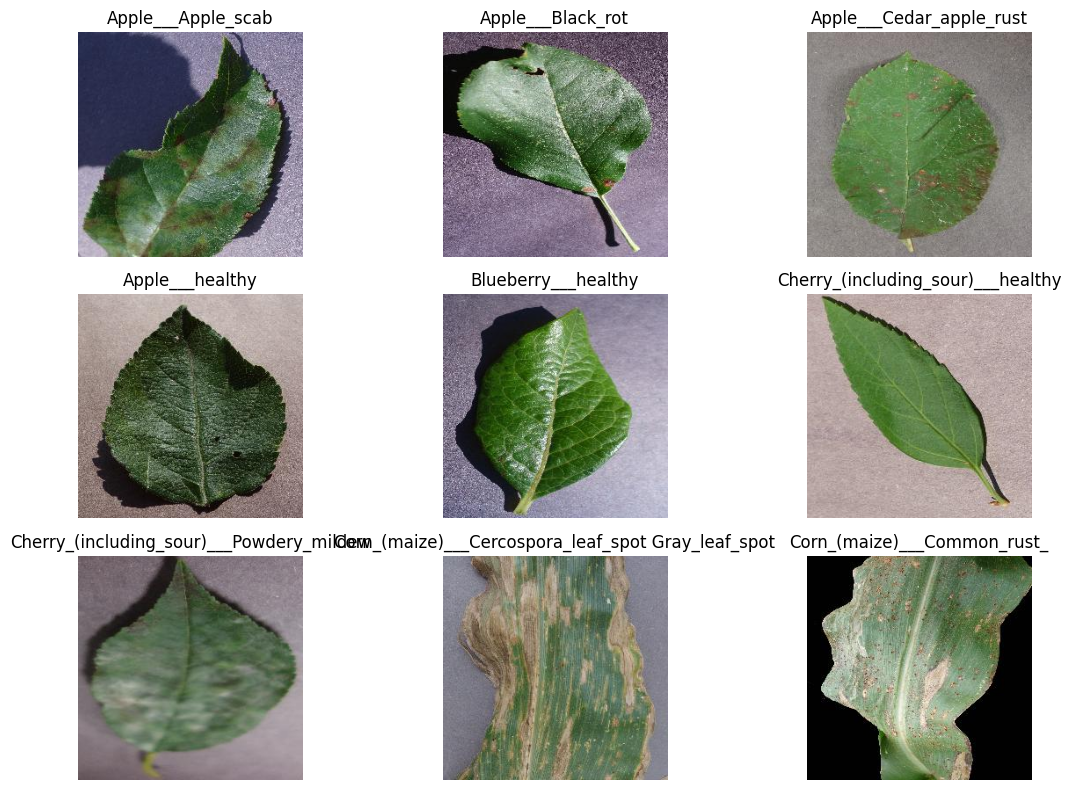

In [7]:
#Sample Image Visualization


plt.figure(figsize=(12,8))

classes = list(class_counts.keys())

for i, class_name in enumerate(classes[:9]):  # first 9 classes
    class_path = data_dir / class_name
    img_name = random.choice(os.listdir(class_path))
    img_path = class_path / img_name
    
    img = plt.imread(img_path)
    
    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [9]:
#Train/Val/Test Split
#Split Function

import shutil

output_dir = Path(r"C:\Users\user\Documents\Agriculture & Smart Farming\PlantVillage_split")

train_dir = output_dir / "train"
val_dir   = output_dir / "val"
test_dir  = output_dir / "test"

for folder in [train_dir, val_dir, test_dir]:
    folder.mkdir(parents=True, exist_ok=True)

train_ratio = 0.7
val_ratio   = 0.15
test_ratio  = 0.15

In [10]:
import os, shutil, random
from pathlib import Path

data_dir = Path(r"C:\Users\user\Documents\Agriculture & Smart Farming\PlantVillage_split")

train_dir = data_dir / "train"
test_dir =  data_dir / "test"

# Split code

for class_name in os.listdir(data_dir):
    class_path = data_dir / class_name
    
     # ✅ skip train/test folders
    if class_name in ['train', 'test']:
        continue

    if not class_path.is_dir():
        continue

    images = [
        img for img in os.listdir(class_path)
        if img.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]

    random.shuffle(images)
    split = int(0.8 * len(images))

    train_images = images[:split]
    test_images = images[split:]

    for split_name, split_images in zip(['train', 'test'], [train_images, test_images]):
        split_dir = data_dir / split_name

        (split_dir / class_name).mkdir(parents=True, exist_ok=True)

        for img in split_images:
            src = class_path / img
            dst = split_dir / class_name / img

            if not dst.exists():   # ✅ avoid overwrite error
                shutil.copy(src, dst)

print("✅ Data Split Done")

✅ Data Split Done


In [11]:
data_dir = r"C:\Users\user\Documents\Agriculture & Smart Farming\PlantVillage_color"


train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(224,224),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(224,224),
    batch_size=32
)







Found 54305 files belonging to 38 classes.
Using 43444 files for training.
Found 54305 files belonging to 38 classes.
Using 10861 files for validation.


In [12]:
#Normalize + Prefetch

normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds   = val_ds.map(lambda x, y: (normalization_layer(x), y))


AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds   = val_ds.prefetch(AUTOTUNE)


In [14]:
def count_images(folder):
    total = 0
    
    for class_name in os.listdir(folder):
        class_path = os.path.join(folder, class_name)
        
        if os.path.isdir(class_path):
            num_images = len(os.listdir(class_path))
            print(f"{class_name}: {num_images}")
            total += num_images
    print(f"👉 Total Images: {total}")
    return total
count_images(data_dir)


Apple___Apple_scab: 630
Apple___Black_rot: 621
Apple___Cedar_apple_rust: 275
Apple___healthy: 1645
Blueberry___healthy: 1502
Cherry_(including_sour)___healthy: 854
Cherry_(including_sour)___Powdery_mildew: 1052
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 513
Corn_(maize)___Common_rust_: 1192
Corn_(maize)___healthy: 1162
Corn_(maize)___Northern_Leaf_Blight: 985
Grape___Black_rot: 1180
Grape___Esca_(Black_Measles): 1383
Grape___healthy: 423
Grape___Leaf_blight_(Isariopsis_Leaf_Spot): 1076
Orange___Haunglongbing_(Citrus_greening): 5507
Peach___Bacterial_spot: 2297
Peach___healthy: 360
Pepper,_bell___Bacterial_spot: 997
Pepper,_bell___healthy: 1478
Potato___Early_blight: 1000
Potato___healthy: 152
Potato___Late_blight: 1000
Raspberry___healthy: 371
Soybean___healthy: 5090
Squash___Powdery_mildew: 1835
Strawberry___healthy: 456
Strawberry___Leaf_scorch: 1109
Tomato___Bacterial_spot: 2127
Tomato___Early_blight: 1000
Tomato___healthy: 1591
Tomato___Late_blight: 1909
Tomato___Leaf_Mold

54305

### WEEK 2: Custom CNN Architecture and Baseline Training


In [25]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator,load_img, img_to_array
from tensorflow.keras.applications import ResNet50, MobileNetV2
from tensorflow.keras.optimizers import Adam


from sklearn.metrics import (
    classification_report, confusion_matrix, 
    accuracy_score, precision_score, recall_score,
    f1_score
)

print("All the libraries imported successfully")

All the libraries imported successfully


In [33]:
base_dir = Path(r"C:\Users\user\Documents\Agriculture & Smart Farming\PlantVillage_split")
train_dir = base_dir / "train"
val_dir = base_dir / "val"
test_dir = base_dir / "test"

MODEL_PATH = "best_cnn model.keras"

# Config
IMG_SIZE = (128, 128)  
BATCH_SIZE = 16
EPOCHS=500
NUM_CLASSES = len(os.listdir(train_dir)) #Auto-detect number of class

print(f" Train : {train_dir}")
print(f" Val : {val_dir}")
print(f" Test : {test_dir}")
print(f" Number of Classes : {NUM_CLASSES}")

 Train : C:\Users\user\Documents\Agriculture & Smart Farming\PlantVillage_split\train
 Val : C:\Users\user\Documents\Agriculture & Smart Farming\PlantVillage_split\val
 Test : C:\Users\user\Documents\Agriculture & Smart Farming\PlantVillage_split\test
 Number of Classes : 38


In [34]:
# Data Augmentation & Image Data Generators
from tensorflow.keras.preprocessing.image import ImageDataGenerator 
#Training generator - With augmention to prevent overfitting

train_datagen = ImageDataGenerator(
    rescale = 1./255,    # Normalize pixels to [0,1]
    rotation_range = 20, # Random rotation ±20 degrees
    width_shift_range = 0.1, #Shift image horizontly
    height_shift_range = 0.1, #shift image vertically
    horizontal_flip = True,  # Flip left-right randomly
    zoom_range = 0.15, #zoom in/out
    brightness_range = [0.8, 1.2], # simulate different lighting
    fill_mode = "nearest"  #fill empty pixels
)

# Validation & test generators - No augmentation, only  normalize
val_test_datagen = ImageDataGenerator(rescale = 1./255)

# Train 
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    class_mode = 'categorical',
   
)

# Validation
val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    class_mode = 'categorical',
    
)

# Test
test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size = IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode = 'categorical',
    shuffle = False
)

NUM_CLASSES= len(train_generator.class_indices)
print(f" Classes loaded: {NUM_CLASSES} classes")
print(f" Train batches : {len(train_generator)}")
print(f" val batches : {len(val_generator)}")
print(f" Test batches : {len(test_generator)}")




Found 37997 images belonging to 38 classes.
Found 8146 images belonging to 38 classes.
Found 8162 images belonging to 38 classes.
 Classes loaded: 38 classes
 Train batches : 2375
 val batches : 510
 Test batches : 511


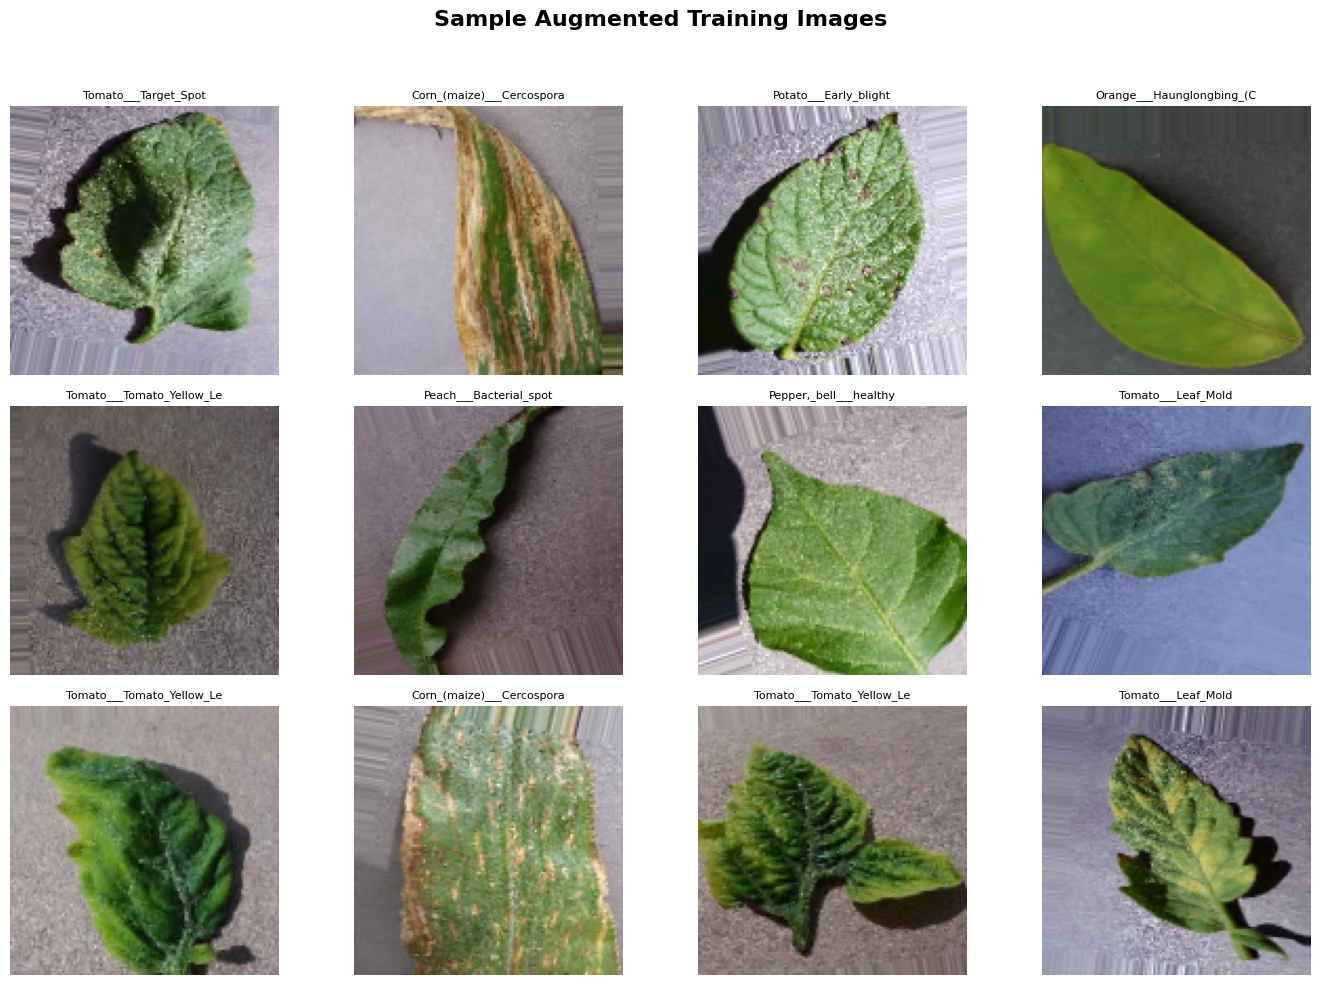

Augmented Sample images displayed


In [35]:
# Visualize Augmented Images (sanity check)
import matplotlib.pyplot as plt
import numpy as np

class_names = list(train_generator.class_indices.keys())

sample_batch, sample_labels = next(train_generator)

fig, axes = plt.subplots(3, 4, figsize =(14, 10))
fig.suptitle('Sample Augmented Training Images', fontsize= 16, fontweight= 'bold')

for i, ax in enumerate(axes.flatten()):
    ax.imshow(sample_batch[i])
    label_idx = np.argmax(sample_labels[i])
    ax.set_title(class_names[label_idx][:25],fontsize=8)
    ax.axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('augmented_samples.png',dpi =100, bbox_inches='tight')
plt.show()
print("Augmented Sample images displayed")

In [ ]:
#  Build Custom CNN Architecture Baseline Model

def build_custom_cnn(num_classes, input_shape=(128, 128, 3)):
    model = models.Sequential([
        # --- Block 1 ---
        layers.Conv2D(32, (3, 3), activation='relu', padding='same',input_shape=(128,128,3)),
        layers.MaxPooling2D(),
        layers.Dropout(0.25),

        # --- Block 2 ---
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D(),
        layers.Dropout(0.25),

        # --- Block 3 ---
        layers.Conv2D(128, (3, 3), activation='relu', padding='same', name='conv3_1'),
        layers.MaxPooling2D(),
        layers.Dropout(0.25),

        # --- Classifier Head ---
        layers.GlobalAveragePooling2D(),      
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),            
        layers.Dense(num_classes, activation='softmax')
    ])
    return model
       
NUM_CLASSES=38 
model = build_custom_cnn(NUM_CLASSES)


model.summary()

C:\Users\user\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_1 (Conv2D)                │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 136,038 (531.40 KB)

 Trainable params: 136,038 (531.40 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Callbacks
#1.Early Stopping - stop training if val_loss doesn't imporve
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,     
    restore_best_weights=True, 
    verbose=1
)

#2.Model Checpoint - save the best model automatically
checkpoint = ModelCheckpoint(
    MODEL_PATH,
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

#3. Reduce Learning Rate -  slow down LR if training stalls
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5, 
    patience=3,
    min_lr=1e-6,
    verbose=1
)


print(f"✅ Calbacks configured")
print("   • EarlyStopping    (patience=5) ")
print("   • ModelCheckpoint  (save best model)")
print("   • ReduceLROnPlateau (patience=3)")


✅ Calbacks configured
   • EarlyStopping    (patience=5) 
   • ModelCheckpoint  (save best model)
   • ReduceLROnPlateau (patience=3)


In [32]:
print("Train:", len(train_generator.class_indices))
print("Val:", len(val_generator.class_indices))

print("\nTrain classes:")
print(train_generator.class_indices)

print("\nVal classes:")
print(val_generator.class_indices)

Train: 38
Val: 38

Train classes:
{'Apple___Apple_scab': 0, 'Apple___Black_rot': 1, 'Apple___Cedar_apple_rust': 2, 'Apple___healthy': 3, 'Blueberry___healthy': 4, 'Cherry_(including_sour)___Powdery_mildew': 5, 'Cherry_(including_sour)___healthy': 6, 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 7, 'Corn_(maize)___Common_rust_': 8, 'Corn_(maize)___Northern_Leaf_Blight': 9, 'Corn_(maize)___healthy': 10, 'Grape___Black_rot': 11, 'Grape___Esca_(Black_Measles)': 12, 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 13, 'Grape___healthy': 14, 'Orange___Haunglongbing_(Citrus_greening)': 15, 'Peach___Bacterial_spot': 16, 'Peach___healthy': 17, 'Pepper,_bell___Bacterial_spot': 18, 'Pepper,_bell___healthy': 19, 'Potato___Early_blight': 20, 'Potato___Late_blight': 21, 'Potato___healthy': 22, 'Raspberry___healthy': 23, 'Soybean___healthy': 24, 'Squash___Powdery_mildew': 25, 'Strawberry___Leaf_scorch': 26, 'Strawberry___healthy': 27, 'Tomato___Bacterial_spot': 28, 'Tomato___Early_blight': 29, '

In [ ]:
# Train the Custom CNN

print("\n🚀 First Training Started  ")
print(f" Batch size : {BATCH_SIZE}")
print(f" Classes  : {NUM_CLASSES}")

model = build_custom_cnn(NUM_CLASSES)

model.compile(
    optimizer = Adam(learning_rate=0.001),
    loss ='categorical_crossentropy',
    metrics =['accuracy']
)

cnn_history1 = model.fit(
    train_generator,
    epochs =EPOCHS,
    validation_data=val_generator,
    callbacks=[early_stop, checkpoint, reduce_lr],
    verbose =1
)

print("✅ First Training done ")
      


🚀 First Training Started  
 epochs : 30(with early stopping)
 Batch size : 16
 Classes  : 38
Epoch 1/500
2375/2375 ━━━━━━━━━━━━━━━━━━━━ 0s 481ms/step - accuracy: 0.2371 - loss: 2.8580
Epoch 1: val_accuracy improved from None to 0.56445, saving model to best_cnn model.keras
2375/2375 ━━━━━━━━━━━━━━━━━━━━ 1270s 533ms/step - accuracy: 0.3384 - loss: 2.4010 - val_accuracy: 0.5644 - val_loss: 1.4601 - learning_rate: 0.0010
Epoch 2/500
2375/2375 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step - accuracy: 0.5604 - loss: 1.4673
Epoch 2: val_accuracy improved from 0.56445 to 0.69654, saving model to best_cnn model.keras
2375/2375 ━━━━━━━━━━━━━━━━━━━━ 842s 355ms/step - accuracy: 0.5929 - loss: 1.3514 - val_accuracy: 0.6965 - val_loss: 1.0269 - learning_rate: 0.0010
Epoch 3/500
2375/2375 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step - accuracy: 0.6690 - loss: 1.0841
Epoch 3: val_accuracy improved from 0.69654 to 0.71962, saving model to best_cnn model.keras
2375/2375 ━━━━━━━━━━━━━━━━━━━━ 917s 386ms/step - accuracy: 0.6

In [ ]:
# +++++++++++++++++++++++++++++++++++++++++
# 🔥 LOAD BEST MODEL
# +++++++++++++++++++++++++++++++++++++++++ 

print("\n🔁 Loading best model for second Training...")
model = tf.keras.models.load_model(MODEL_PATH)

# lower LR for  fine-turing
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=['accuracy']
)

In [ ]:
# ===============================================
# 🔥 SECOND TRAINING STARTED
# ===============================================

print("\n🚀 SECOND TRAINING STARTED")

cnn_history2 = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data = val_generator,
    callbacks=[early_stop, checkpoint, reduce_lr],
    verbose = 1
)

print("✅ Second training done")


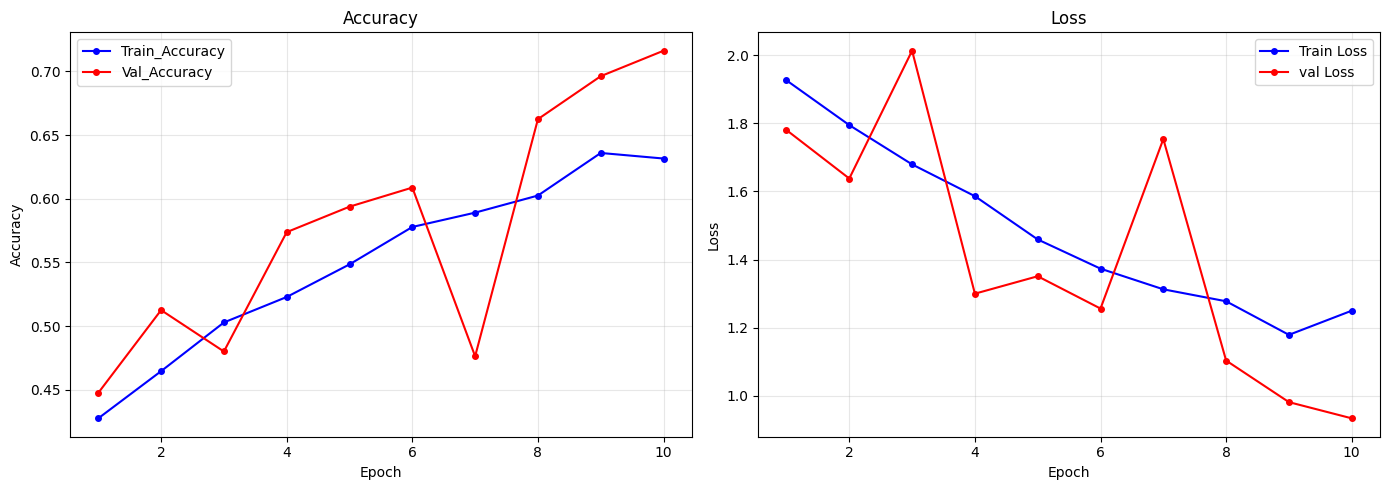


 Best Validation Accuracy (Custom CNN): 0.7163 (71.63%)


In [ ]:
# Plot Tarining & Validation Loss/Accuracy Curves
import matplotlib.pylab as plt
import tensorflow as tf

def plot_training_history(history, model_name="Model"):
    fix, axes = plt.subplots(1, 2, figsize =(14, 5))
    fig.suptitle(f'{model_name} - Training History', fontsize=14, fontweight='bold')

    epochs_ran = range(1, len(history.history['accuracy']) + 1)

    # Accuracy Plot
    axes[0].plot(epochs_ran,history.history['accuracy'],  'b-o', label='Train_Accuracy', markersize=4)
    axes[0].plot(epochs_ran, history.history['val_accuracy'], 'r-o', label='Val_Accuracy',markersize=4)
    axes[0].set_title('Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

# Loss Plot 
    axes[1].plot(epochs_ran,history.history['loss'], 'b-o', label='Train Loss', markersize=4)
    axes[1].plot(epochs_ran,history.history['val_loss'], 'r-o', label='val Loss', markersize=4)
    axes[1].set_title('Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{model_name.replace(" ", "_")}_history.png', dpi =100, bbox_inches='tight')
    plt.show()

# ===============================================
# SELECT WHICH HISTORY TO USE
# ===============================================
cnn_history = cnn_history2
# cnn_history = cnn_history1

# ==============================================
# Run Plot  + Best Val ACC
# ==============================================
plot_training_history(cnn_history, "Custom CNN")

if 'val_accuracy' in cnn_history.history:
    best_val_acc = max(cnn_history.history['val_accuracy'])
    print(f"\n🔥 Best Validation Accuracy (Custom CNN): {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")
else:
    print(" ⚠️ No validation accuracy found!")

# ==========================================================
# TEST BEST MODEL
# ==========================================================

print("\n🧪 Testing final best model...")

model = tf.keras.models.load_model(MODEL_PATH)

test_loss, test_acc = model.evaluate(test_generator)

print(f"🔥  Final Test Accuracy: {test_acc:.4f} ")
    